# Descargar dataset de Kaggle

In [3]:
import kagglehub
import pandas as pd

# 1. Descargar automáticamente el dataset de Kaggle
print("Descargando dataset...")
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("¡Descarga completada con éxito!")
print("Los archivos se guardaron en la ruta:", path)

# 2. Cargar el archivo creditcard.csv en Python
import os
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

# 3. Mostrar las primeras 5 transacciones
df.head()

Descargando dataset...


100%|██████████| 66.0M/66.0M [01:36<00:00, 718kB/s]

Extracting files...


¡Descarga completada con éxito!
Los archivos se guardaron en la ruta: C:\Users\Usuario\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Contar fraudes y sacar el prior

In [6]:
# Contar cuántas transacciones son legítumas y cuáles son fraude
conteo_clases = df['Class'].value_counts()
# Todas las transacciones
total_transacciones = len(df)

legitimas = conteo_clases[0]  # Toma las legítimas
fraudes = conteo_clases[1]    # Toma los fraudes

# Imprime el número de transacciones
print(f"Transacciones legítimas guardadas: {legitimas}")
print(f"Transacciones fraudulentas guardadas: {fraudes}")

Transacciones legítimas guardadas: 284315
Transacciones fraudulentas guardadas: 492


# Probabilidad inicial (Prior)

In [7]:
# Prior legítimas
prior_legitimas = (legitimas/total_transacciones)*100

# Prior fraude
prior_fraude = (fraudes/total_transacciones)*100

# Imprime las prior
print(f"Transacciones legítimas (Clase 0): {legitimas:,} ({prior_legitimas:.5f}%)")
print(f"Transacciones fraudulentas (Clase 1): {fraudes:,} ({prior_fraude:.5f}%)")

Transacciones legítimas (Clase 0): 284,315 (99.82725%)
Transacciones fraudulentas (Clase 1): 492 (0.17275%)


# Esperanza y Varianza por clase

In [14]:
# Filtramos por la clase los montos de las transacciones
montos_legitimas = df.query("Class == 0")["Amount"]
montos_fraudes = df.query("Class == 1")["Amount"]

# 2. Calcular la Esperanza (Promedio) para cada grupo
esperanza_legitimas = montos_legitimas.mean()
esperanza_fraudes = montos_fraudes.mean()

# 3. Calcular la Varianza para cada grupo
varianza_legitimas = montos_legitimas.var()
varianza_fraudes = montos_fraudes.var()

# 4. Mostrar los resultados en pantalla
print(f"Transacciones Legítimas:")
print(f"  - Esperanza (Monto promedio): ${esperanza_legitimas:.2f}")
print(f"  - Varianza (Dispersión): ${varianza_legitimas:,.2f}\n")

print(f"Transacciones Fraudulentas:")
print(f"  - Esperanza (Monto promedio): ${esperanza_fraudes:.2f}")
print(f"  - Varianza (Dispersión): ${varianza_fraudes:,.2f}")

Transacciones Legítimas:
  - Esperanza (Monto promedio): $88.29
  - Varianza (Dispersión): $62,552.56

Transacciones Fraudulentas:
  - Esperanza (Monto promedio): $122.21
  - Varianza (Dispersión): $65,886.31


# Probabilidad condicional

In [16]:
# Definimos tres umbrales de dinero para evaluar: $100, $500 y $1000
umbrales = [100, 500, 1000]

# Calculamos el prior global de fraude
prior_global_porcentaje = (df["Class"].sum() / len(df)) * 100

print(f"Prior global de fraude: {prior_global_porcentaje:.4f}%\n")

for X in umbrales:
    # 1. Filtramos las transacciones que superan el monto X
    tx_mayores_X = df.query(f"Amount > {X}")
    total_mayores_X = len(tx_mayores_X)
    
    # 2. Contamos cuántos fraudes hay en ese grupo
    fraudes_mayores_X = tx_mayores_X["Class"].sum()
    
    # 3. Calculamos la probabilidad condicional
    prob_condicional = (
        (fraudes_mayores_X / total_mayores_X) * 100
        if total_mayores_X > 0
        else 0
    )
    
    # 4. Mostramos el resultado
    print(f"Para compras mayores a ${X}:")
    print(f"  - Total transacciones: {total_mayores_X:,}")
    print(f"  - Fraudes detectados: {fraudes_mayores_X:,}")
    print(f"  - P(Fraude | Monto > ${X}) = {prob_condicional:.4f}%\n")

Prior global de fraude: 0.1727%

Para compras mayores a $100:
  - Total transacciones: 56,508
  - Fraudes detectados: 130
  - P(Fraude | Monto > $100) = 0.2301%

Para compras mayores a $500:
  - Total transacciones: 9,142
  - Fraudes detectados: 35
  - P(Fraude | Monto > $500) = 0.3828%

Para compras mayores a $1000:
  - Total transacciones: 2,940
  - Fraudes detectados: 9
  - P(Fraude | Monto > $1000) = 0.3061%



# Teorema de Bayes y Falsos Positivos

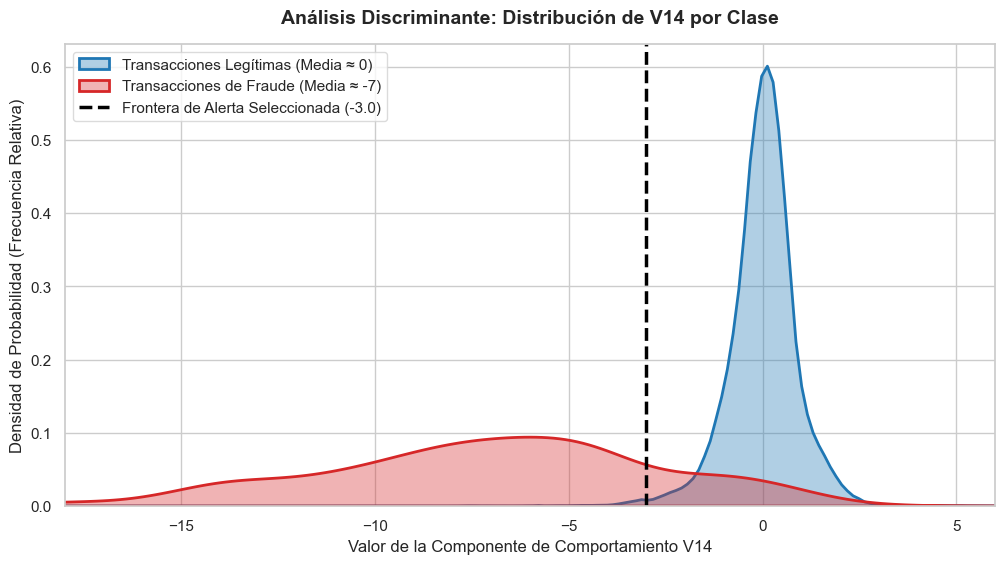

In [19]:
# Vemos el comportamiento de una de las variables (V14) para ambas clases
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño del lienzo y el estilo visual
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. Dibujar la campana azul para transacciones legítimas (Class == 0)
sns.kdeplot(
    data=df[df['Class'] == 0], 
    x='V14', 
    fill=True, 
    color='#1f77b4',  # Azul corporativo
    label='Transacciones Legítimas (Media ≈ 0)', 
    alpha=0.35,
    linewidth=2
)

# 3. Dibujar la campana roja para fraudes (Class == 1)
sns.kdeplot(
    data=df[df['Class'] == 1], 
    x='V14', 
    fill=True, 
    color='#d62728',  # Rojo de alerta
    label='Transacciones de Fraude (Media ≈ -7)', 
    alpha=0.35,
    linewidth=2
)

# 4. Trazar la frontera de decisión en -3.0 (Línea discontinua negra)
plt.axvline(
    x=-3.0, 
    color='black', 
    linestyle='--', 
    linewidth=2.5, 
    label='Frontera de Alerta Seleccionada (-3.0)'
)

# 5. Personalizar títulos y etiquetas con tono de consultoría profesional
plt.title('Análisis Discriminante: Distribución de V14 por Clase', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valor de la Componente de Comportamiento V14', fontsize=12)
plt.ylabel('Densidad de Probabilidad (Frecuencia Relativa)', fontsize=12)

# Ajustamos los límites del eje X para centrar la visualización en la zona clave
plt.xlim([-18, 6]) 

# Configurar la leyenda para que sea clara y profesional
plt.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', edgecolor='lightgrey')
plt.savefig('grafico_v14_comportamiento.png', dpi=300, bbox_inches='tight')

# 6. Mostrar la gráfica en tu pantalla de Jupyter
plt.show()

In [17]:
# 1. Definimos la regla del "filtro": si V14 es menor a -3.0, generamos alerta
umbral_v14 = -3.0
df["alerta_fraude"] = df["V14"] < umbral_v14

# 2. Sensibilidad: P(Alerta = True | Fraude Real)
total_fraudes_reales = len(df[df["Class"] == 1])
fraudes_detectados = len(df[(df["Class"] == 1) & (df["alerta_fraude"] == True)])
sensibilidad = fraudes_detectados / total_fraudes_reales

# 3. Especificidad: P(Alerta = False | Legítima Real)
total_legitimas_reales = len(df[df["Class"] == 0])
legitimas_sin_alerta = len(df[(df["Class"] == 0) & (df["alerta_fraude"] == False)])
especificidad = legitimas_sin_alerta / total_legitimas_reales

# Tasa de Falsos Positivos (FPR): P(Alerta = True | Legítima Real)
tasa_falsos_positivos = 1 - especificidad

# 4. TEOREMA DE BAYES (Cálculo de la Probabilidad Posterior)

# Bayes: P(Fraude | Alerta) = P(Alerta|Fraude) * P(Fraude) / P(Alerta)
probabilidad_alerta = (sensibilidad * prior_fraude) + (tasa_falsos_positivos * prior_legitimas)
posterior_fraude_dado_alerta = (sensibilidad * prior_fraude) / probabilidad_alerta

# 5. Imprimir los resultados estadísticos
print(f"Regla de Alerta Evaluada: V14 < {umbral_v14}\n")
print(f"1. Sensibilidad de la alerta: {sensibilidad*100:.2f}%")
print(f"   (Atrapa {fraudes_detectados} de los {total_fraudes_reales} fraudes reales)\n")
print(f"2. Especificidad de la alerta: {especificidad*100:.2f}%")
print(f"   (Deja pasar correctamente al {especificidad*100:.2f}% de los clientes normales)")
print(f"   (Tasa de Falsos Positivos FPR: {tasa_falsos_positivos*100:.4f}%)\n")
print(f"3. APLICANDO TEOREMA DE BAYES:")
print(f"   Probabilidad Posterior Real P(Fraude | Alerta) = {posterior_fraude_dado_alerta*100:.2f}%")

Regla de Alerta Evaluada: V14 < -3.0

1. Sensibilidad de la alerta: 82.32%
   (Atrapa 405 de los 492 fraudes reales)

2. Especificidad de la alerta: 99.30%
   (Deja pasar correctamente al 99.30% de los clientes normales)
   (Tasa de Falsos Positivos FPR: 0.6975%)

3. APLICANDO TEOREMA DE BAYES:
   Probabilidad Posterior Real P(Fraude | Alerta) = 16.96%


# MLE y Q-Q Plot

Para la componente V14 (Transacciones Legítimas):
  - μ (Media estimada por MLE): 0.0121
  - σ (Desviación estándar estimada por MLE): 0.8970

Para la componente V14 (Transacciones de Fraude):
  - μ (Media estimada por MLE): -6.9717
  - σ (Desviación estándar estimada por MLE): 4.2746



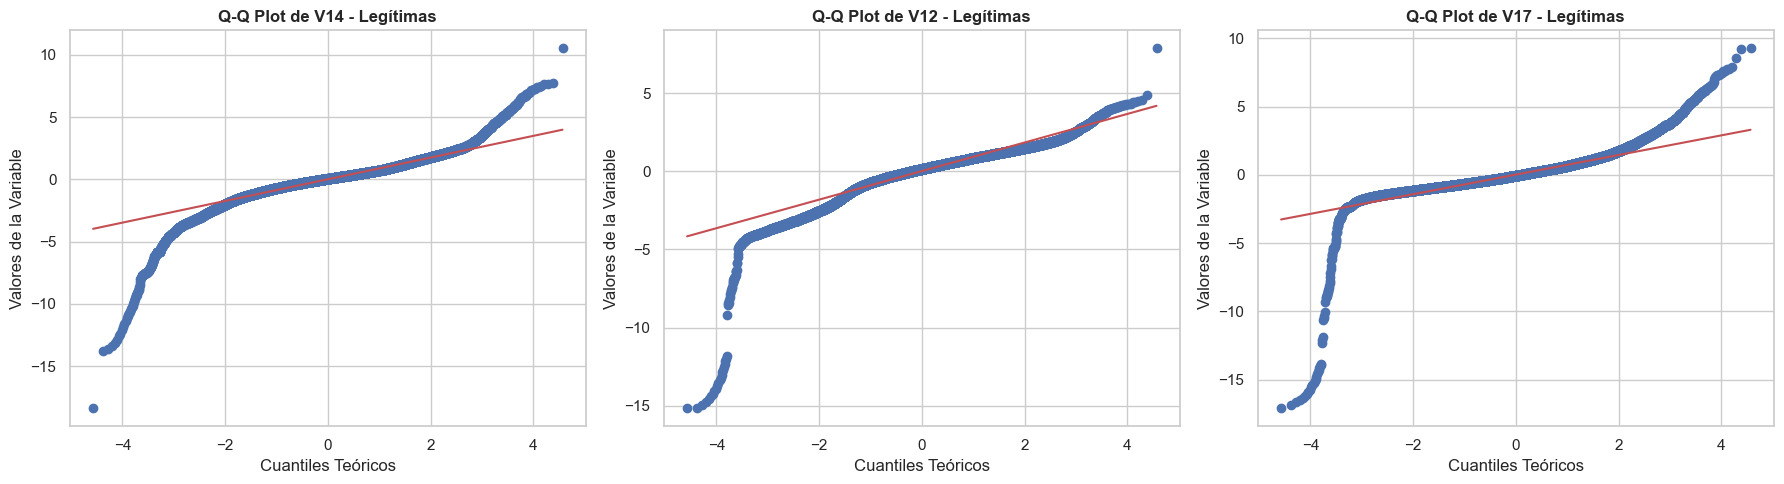

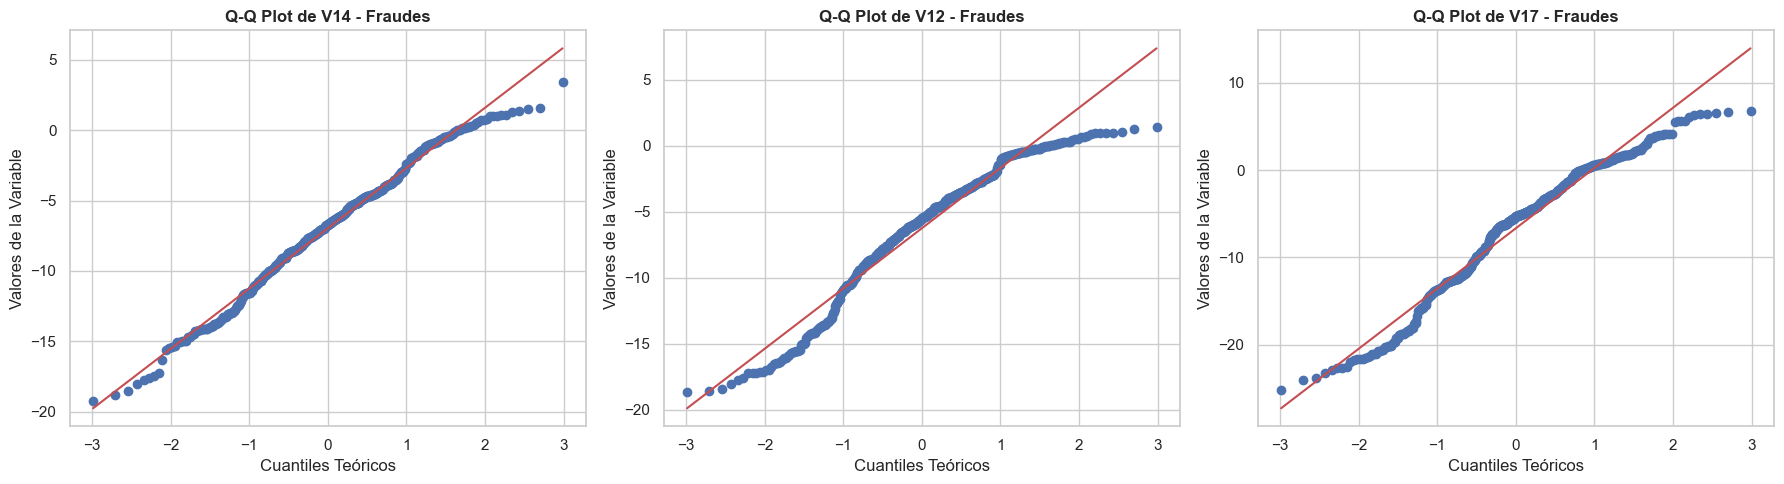

In [21]:
from scipy import stats
import matplotlib.pyplot as plt

# 1. SEPARAMOS LAS TRANSACCIONES POR CLASE

df_legitimas = df.query("Class == 0")
df_fraudes = df.query("Class == 1")

# 2. MLE PARA V14

v14_legitimas = df_legitimas["V14"]
v14_fraudes = df_fraudes["V14"]

# Ajuste MLE a una distribución Normal
mu_legit_mle, std_legit_mle = stats.norm.fit(v14_legitimas)
mu_fraud_mle, std_fraud_mle = stats.norm.fit(v14_fraudes)

print("Para la componente V14 (Transacciones Legítimas):")
print(f"  - μ (Media estimada por MLE): {mu_legit_mle:.4f}")
print(f"  - σ (Desviación estándar estimada por MLE): {std_legit_mle:.4f}\n")

print("Para la componente V14 (Transacciones de Fraude):")
print(f"  - μ (Media estimada por MLE): {mu_fraud_mle:.4f}")
print(f"  - σ (Desviación estándar estimada por MLE): {std_fraud_mle:.4f}\n")

# 3. Q-Q PLOTS PARA TRANSACCIONES LEGÍTIMAS

componentes = ["V14", "V12", "V17"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(componentes):
    stats.probplot(
        df_legitimas[col],
        dist="norm",
        plot=axes[i]
    )
    
    axes[i].set_title(
        f"Q-Q Plot de {col} - Legítimas",
        fontsize=12,
        fontweight="bold"
    )
    
    axes[i].set_xlabel("Cuantiles Teóricos")
    axes[i].set_ylabel("Valores de la Variable")

plt.tight_layout()

plt.savefig(
    "qq_plots_legitimas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 4. Q-Q PLOTS PARA TRANSACCIONES FRAUDULENTAS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(componentes):
    stats.probplot(
        df_fraudes[col],
        dist="norm",
        plot=axes[i]
    )
    
    axes[i].set_title(
        f"Q-Q Plot de {col} - Fraudes",
        fontsize=12,
        fontweight="bold"
    )
    
    axes[i].set_xlabel("Cuantiles Teóricos")
    axes[i].set_ylabel("Valores de la Variable")

plt.tight_layout()

plt.savefig(
    "qq_plots_fraudes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Correlación

In [22]:
# 1. Seleccionamos componentes para verificar su independencia mutua
comp_v1 = 'V1'
comp_v2 = 'V2'
comp_v14 = 'V14'
comp_v15 = 'V15'

# Calculamos la correlación de Pearson entre componentes PCA
corr_v1_v2 = df[comp_v1].corr(df[comp_v2])
corr_v14_v15 = df[comp_v14].corr(df[comp_v15])

# 2. Calcular la correlación de 'Amount' y 'Time' con 'Class'
corr_amount_class = df['Amount'].corr(df['Class'])
corr_time_class = df['Time'].corr(df['Class'])

# 3. Mostrar los resultados de forma profesional
print("1. Correlación entre componentes PCA (Ortogonalidad por diseño):")
print(f"   - Correlación ({comp_v1} vs {comp_v2}): {corr_v1_v2:.2e}")
print(f"   - Correlación ({comp_v14} vs {comp_v15}): {corr_v14_v15:.2e}\n")

print("2. Correlación de variables originales con la Clase de transacción:")
print(f"   - Correlación (Monto 'Amount' vs Clase): {corr_amount_class:.5f}")
print(f"   - Correlación (Tiempo 'Time' vs Clase): {corr_time_class:.5f}")

1. Correlación entre componentes PCA (Ortogonalidad por diseño):
   - Correlación (V1 vs V2): -9.98e-17
   - Correlación (V14 vs V15): -3.14e-16

2. Correlación de variables originales con la Clase de transacción:
   - Correlación (Monto 'Amount' vs Clase): 0.00563
   - Correlación (Tiempo 'Time' vs Clase): -0.01232


# Entropía

In [26]:
import numpy as np

# 1. Contamos el total de registros en el dataset (284,807)
total_registros = len(df)

# 2. Calculamos las probabilidades de forma escalar y segura usando .get()
conteos = df['Class'].value_counts()
p_legitima = conteos.get(0, 0) / total_registros
p_fraude = conteos.get(1, 0) / total_registros

# 3. Aplicamos la fórmula matemática de la Entropía de Shannon (base 2)
# H(Class) = - [ P(0)*log2(P(0)) + P(1)*log2(P(1)) ]
entropia_class = - (p_legitima * np.log2(p_legitima) + p_fraude * np.log2(p_fraude))

print(f"Probabilidad de Transacción Legítima P(Clase 0): {p_legitima*100:.5f}%")
print(f"Probabilidad de Transacción de Fraude P(Clase 1): {p_fraude*100:.5f}%\n")
print(f"Entropía real de la variable 'Class': {entropia_class:.5f} bits")
print(f"Entropía máxima teórica (si estuviera 50/50 balanceado): 1.00000 bits")

Probabilidad de Transacción Legítima P(Clase 0): 99.82725%
Probabilidad de Transacción de Fraude P(Clase 1): 0.17275%

Entropía real de la variable 'Class': 0.01834 bits
Entropía máxima teórica (si estuviera 50/50 balanceado): 1.00000 bits


# Escalado y Entropía Cruzada

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, classification_report

print("--- INICIANDO FASE DE PREPROCESAMIENTO ---")

# 1. Copiar el DataFrame para preservar los datos originales de los análisis previos
df_procesado = df.copy()

# 2. ESCALADO: Ajustamos 'Time' y 'Amount' para que tengan media 0 y varianza 1
# Esto es vital para que estén en la misma escala Z-score que las componentes PCA (V1-V28)
scaler = StandardScaler()
df_procesado[['Time', 'Amount']] = scaler.fit_transform(df_procesado[['Time', 'Amount']])
print("[OK] Variables 'Time' y 'Amount' escaladas con StandardScaler.\n")

# 3. DIVISIÓN DE DATOS: Separamos características (X) de la etiqueta objetivo (y)
X = df_procesado.drop(columns=['Class'])
y = df_procesado['Class']

# Usamos estratificación (stratify=y) para garantizar que el train y test sets 
# conserven exactamente la proporción original del prior de fraude (0.172%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- ENTRENAMIENTO Y CÁLCULO DE ENTROPÍA CRUZADA ---")

# 4. MODELO ESTÁNDAR (Ignora el desbalance)
model_estandar = LogisticRegression(max_iter=1000, random_state=42)
model_estandar.fit(X_train, y_train)

# 5. MODELO BALANCEADO (Aplica pesos inversamente proporcionales a las frecuencias de clase)
model_balanceado = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_balanceado.fit(X_train, y_train)

# 6. EVALUACIÓN DE LA PÉRDIDA POR ENTROPÍA CRUZADA (LOG LOSS)
prob_estandar = model_estandar.predict_proba(X_test)
loss_estandar = log_loss(y_test, prob_estandar)

prob_balanceado = model_balanceado.predict_proba(X_test)
loss_balanceado = log_loss(y_test, prob_balanceado)

print(f"1. Entropía Cruzada Promedio (Modelo Estándar):   {loss_estandar:.6f}")
print(f"2. Entropía Cruzada Promedio (Modelo Balanceado):  {loss_balanceado:.6f}\n")

# 7. METRICAS DE CLASIFICACIÓN DETALLADAS (RECALL vs PRECISION)
print("=== REPORTE DE DESEMPEÑO DEL MODELO BALANCEADO ===")
preds_balanceadas = model_balanceado.predict(X_test)
print(classification_report(y_test, preds_balanceadas, digits=4))

--- INICIANDO FASE DE PREPROCESAMIENTO ---
[OK] Variables 'Time' y 'Amount' escaladas con StandardScaler.

--- ENTRENAMIENTO Y CÁLCULO DE ENTROPÍA CRUZADA ---
1. Entropía Cruzada Promedio (Modelo Estándar):   0.004483
2. Entropía Cruzada Promedio (Modelo Balanceado):  0.109629

=== REPORTE DE DESEMPEÑO DEL MODELO BALANCEADO ===
              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0579    0.9184    0.1090        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5479     56962
weighted avg     0.9982    0.9742    0.9854     56962



# Divergencia KL

In [29]:
import numpy as np
import pandas as pd

def calcular_kl_divergencia(df, columna, n_bins=20):
    # 1. Separar las poblaciones de legítimas y fraudes
    x_legitimas = df.query("Class == 0")[columna]
    x_fraudes = df.query("Class == 1")[columna]
    
    # 2. Definir bins comunes basados en el rango total de la variable
    min_val = df[columna].min()
    max_val = df[columna].max()
    bins = np.linspace(min_val, max_val, n_bins + 1)
    
    # 3. Calcular histogramas (conteos por intervalo)
    hist_legit, _ = np.histogram(x_legitimas, bins=bins)
    hist_fraud, _ = np.histogram(x_fraudes, bins=bins)
    
    # 4. Aplicar suavizado de Laplace para evitar divisiones por cero o log(0)
    # Añadimos un valor minúsculo (1e-5) a los bins vacíos
    p_counts = hist_fraud + 1e-5
    q_counts = hist_legit + 1e-5
    
    # 5. Convertir a distribuciones de probabilidad (deben sumar 1.0)
    p = p_counts / p_counts.sum()  # Distribución de Fraude (P)
    q = q_counts / q_counts.sum()  # Distribución de Legítimas (Q)
    
    # 6. Calcular KL(P || Q) en bits usando logaritmo base 2
    kl = np.sum(p * np.log2(p / q))
    return kl

# 7. Calcular la Divergencia KL para las 28 componentes PCA
resultados_kl = []
for i in range(1, 29):
    col = f'V{i}'
    kl_val = calcular_kl_divergencia(df, col)
    resultados_kl.append({'Variable': col, 'Divergencia_KL_bits': kl_val})

# Convertir a DataFrame y ordenar de mayor a menor relevancia
df_kl_ranking = pd.DataFrame(resultados_kl).sort_values(by='Divergencia_KL_bits', ascending=False)

print("Top 5 componentes más informativas para el banco:")
print(df_kl_ranking.head(5).to_string(index=False))
print("\nBottom 5 componentes menos informativas (ruido):")
print(df_kl_ranking.tail(5).to_string(index=False))

Top 5 componentes más informativas para el banco:
Variable  Divergencia_KL_bits
     V17             9.112634
     V12             8.745036
     V14             7.911942
     V10             7.411210
     V16             6.913636

Bottom 5 componentes menos informativas (ruido):
Variable  Divergencia_KL_bits
     V24             0.120425
     V20             0.101039
     V26             0.081015
     V13             0.059623
     V15             0.047727
